# Overfitting

In [108]:
import numpy as np
import matplotlib.pyplot as plt

Define data $(X_i,Y_i)$ for $i=1,\ldots, n$ where $$Y_i = \cos(\frac{3\pi}{2} X_i) + \xi_i,$$  $\xi_i \sim \mathcal{N}(0,\sigma^2)$ and $X_i \sim \mathrm{Unif}(0,1)$.


In [109]:
def f(x):
    return np.cos(1.5*np.pi*x)

# data
n = 15
sigma =  0.1
np.random.seed(0)
X = np.sort(np.random.rand(n))
y = f(X) + np.random.randn(n) *sigma

Let's find a function $h$ to predict $y$ given $x$:


Consider fitting this data with the polynomial $h_w(x) = \sum_{k=0}^d w_k x^k$. Let's find the approximation that fits best wrt quadratic loss
$$
\min_{w\in\mathbb{R}^{d+1}} \sum_{i=1}^n (h_w(X_i) - Y_i)^2.
$$
Letting $\mathbf{Y} = (Y_i)$ and $\mathbf{M}_{i,j} = X_i^j$, this is equivalent to solving
$$
\min_w\|\mathbf{M} w - \mathbf{Y}\|^2.
$$
So, $w$ solves $\mathbf{M}^\top \mathbf{M} w = \mathbf{M}^\top \mathbf{Y}$.

In [112]:
# X = (n,) is a vector of length n
# Y = (n,) is a vector of length n
# d is the polynomial degree
def fit_data( X, y, d):
    
    Matrix = (X[:,None]**np.arange(d+1))
    w = np.linalg.solve(Matrix.T@Matrix, Matrix.T@y)
    
    #print(np.linalg.cond(Matrix))
    def h(X):
        return (X[:,None]**np.arange(d+1))@w
    
    return h


degree=1, training error= 0.18817934702541947 testing error= 0.2923015735969185
degree=5, training error= 0.0016238602872829168 testing error= 0.013080192891448586
degree=20, training error= 0.005019981626383518 testing error= 24454.266765047676


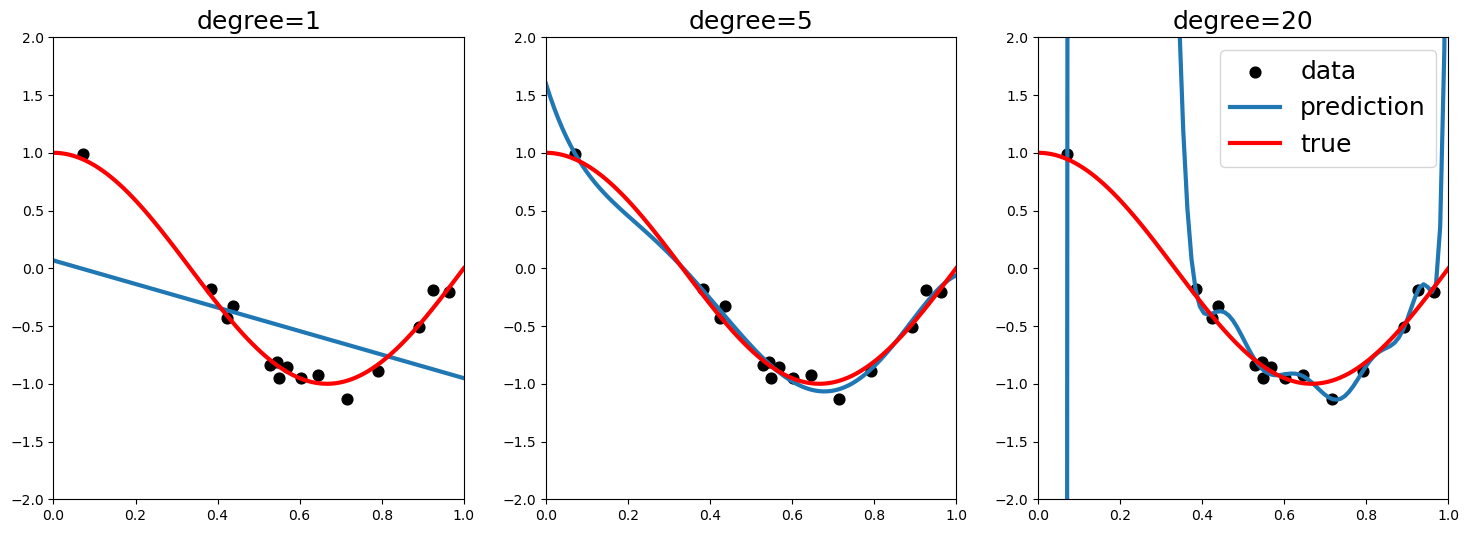

In [113]:
# test our estimator for different degrees
deg = [1, 5, 20]

fig, ax = plt.subplots(1, len(deg), figsize=(18,6))


for i,d in enumerate(deg):
    
    # compute our estimator
    h = fit_data(X,y, d)

    #evaluate estimator on new data
    X_test = np.linspace(0,1,100)
    y_test = h(X_test)
    
    print('degree='+str(d) + ',',
            'training error=', np.linalg.norm(f(X) - h(X))**2/len(y), 
            'testing error=', np.linalg.norm(f(X_test) - h(X_test))**2/len(y_test)  )
    
    ax[i].scatter(X, y, color='k', label='data',s=60)
    ax[i].plot(X_test,y_test,linewidth=3,label='prediction')
    ax[i].plot(X_test, f(X_test),'r',linewidth=3,label='true')
    

    ax[i].set_xlim((0, 1))
    ax[i].set_ylim((-2, 2))
    if i == len(deg)-1:
        ax[i].legend(loc="best", fontsize=18)
    ax[i].set_title('degree='+str(d), fontsize=18)